# Tutorial 04 — Redes neurais como espaços de aproximação

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 4)
torch.manual_seed(SEED + 4)
OUT = ROOT / "estudos" / "tutorial_04" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 4, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260912 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## Protocolo das comparações

O objetivo não é coroar uma família universalmente melhor. Defino previamente os tamanhos de treino, número de épocas, arquitetura e sementes; o teste mede esses ajustes, não escolhe hiperparâmetros. As curvas registram a dependência do orçamento de otimização. Conto parâmetros **efetivos** da restrição polinomial à esfera: $(D+1)^2$; contar monômios redundantes inflaria artificialmente o orçamento polinomial.

Os alvos do original são $g_1=f^\star$ (harmônicos até grau 3), $g_2$ uma gaussiana estreita e $g_3=|z|$. O crossover do exercício 1(a) é, portanto, entre $g_1$ e $g_3$, não entre $g_1$ e a gaussiana.

## Exercício 1

> **Exercise 1 — where is the crossover?**
> (a) Interpolate between $g_1$ and $g_3$ by fitting $g_\alpha = (1-\alpha)g_1 +
> \alpha g_3$ for $\alpha \in [0,1]$, and find the $\alpha$ at which the MLP
> overtakes the polynomial at fixed parameter count.
>
> (b) Repeat the kink experiment with `act=torch.nn.ReLU`. A ReLU network is
> piecewise linear; does that help or hurt on $|z|$, and on the smooth bump?
>
> (c) Sweep $N_{\text{train}}$ and plot test MSE against $N$ for both families on
> the bump. Which has the steeper learning curve, and what does that say about
> which to reach for when data is expensive?

### Resolução

**(a)** Comparo grau 5 na esfera (36 coeficientes harmônicos) com uma MLP de uma camada oculta de largura 7 (36 parâmetros: $3\cdot7+7+7+1$). A mesma amostra serve a todos os $\alpha$. O código indica o primeiro $\alpha$ da grade em que a média das sementes da rede é menor. Se não houver cruzamento, a resposta correta é “não observado nessa configuração”. A grade dá um intervalo, não um ponto universal: mais épocas, ativação ou arquitetura podem deslocá-lo.

**(b)** $|z|=\operatorname{ReLU}(z)+\operatorname{ReLU}(-z)$ é representável **exatamente** por duas unidades. Isso demonstra vantagem de representação, não garante que o otimizador encontre esses pesos. Uma rede ReLU finita é por partes afim, logo não representa exatamente a gaussiana suave em um aberto; pode aproximá-la. Comparo treinamentos Tanh/ReLU para os dois alvos e verifico também a solução ReLU construída à mão.

**(c)** Repito o ajuste da gaussiana em cinco tamanhos de treino e três sementes. Reporto inclinações empíricas e dispersão. Um declive mais íngreme em uma faixa não implica sempre menor erro absoluto; para dados caros importa o erro no orçamento relevante. Um platô pode ser erro de aproximação ou de otimização, não ruído irredutível, pois aqui os alvos são exatos.

 alpha  semente  MSE_polinomio  MSE_MLP
 0.000        0   1.507412e-30 0.003518
 0.000        1   1.507412e-30 0.002162
 0.000        2   1.507412e-30 0.002654
 0.125        0   2.104981e-05 0.005053
 0.125        1   2.104981e-05 0.001822
 0.125        2   2.104981e-05 0.002211
 0.250        0   8.419925e-05 0.002408
 0.250        1   8.419925e-05 0.001583
 0.250        2   8.419925e-05 0.001757
 0.375        0   1.894483e-04 0.001673
 0.375        1   1.894483e-04 0.001064
 0.375        2   1.894483e-04 0.001642
 0.500        0   3.367970e-04 0.001114
 0.500        1   3.367970e-04 0.000692
 0.500        2   3.367970e-04 0.001585
 0.625        0   5.262453e-04 0.000699
 0.625        1   5.262453e-04 0.000567
 0.625        2   5.262453e-04 0.001177
 0.750        0   7.577933e-04 0.000517
 0.750        1   7.577933e-04 0.000401
 0.750        2   7.577933e-04 0.001776
 0.875        0   1.031441e-03 0.000595
 0.875        1   1.031441e-03 0.000526
 0.875        2   1.031441e-03 0.002208


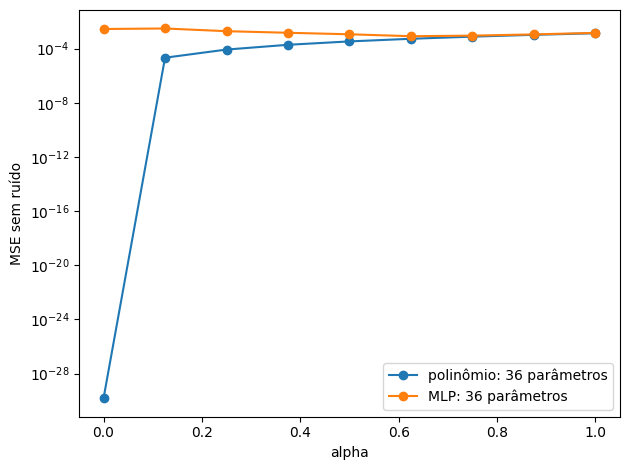

     alvo ativacao  semente      MSE
     kink     Tanh        0 0.000112
     kink     Tanh        1 0.000060
     kink     ReLU        0 0.000023
     kink     ReLU        1 0.000038
gaussiana     Tanh        0 0.000198
gaussiana     Tanh        1 0.000088
gaussiana     ReLU        0 0.000019
gaussiana     ReLU        1 0.000061
Representação ReLU exata de |z| verificada.


   N  semente    modelo      MSE
  80        0 polinômio 0.001972
  80        0       MLP 0.008288
  80        1 polinômio 0.004679
  80        1       MLP 0.007636
  80        2 polinômio 0.002333
  80        2       MLP 0.008585
 160        0 polinômio 0.001232
 160        0       MLP 0.006282
 160        1 polinômio 0.001207
 160        1       MLP 0.009243
 160        2 polinômio 0.001349
 160        2       MLP 0.006161
 400        0 polinômio 0.001249
 400        0       MLP 0.007138
 400        1 polinômio 0.001231
 400        1       MLP 0.008289
 400        2 polinômio 0.001354
 400        2       MLP 0.005002
1000        0 polinômio 0.001128
1000        0       MLP 0.006317
1000        1 polinômio 0.001164
1000        1       MLP 0.007178
1000        2 polinômio 0.001207
1000        2       MLP 0.004433
2500        0 polinômio 0.001113
2500        0       MLP 0.006502
2500        1 polinômio 0.001112
2500        1       MLP 0.007352
2500        2 polinômio 0.001120
2500      

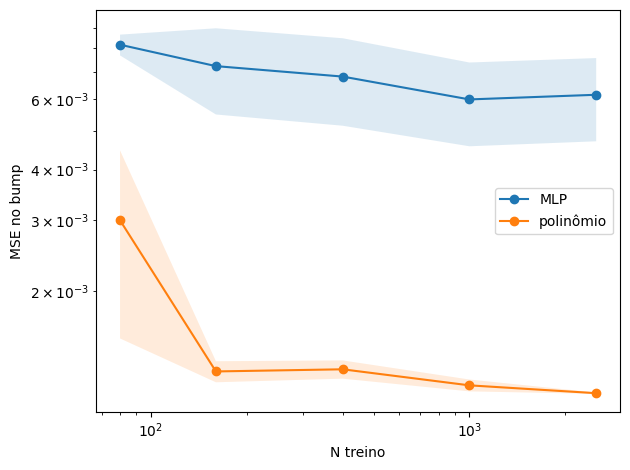

In [2]:
Xt=fibonacci(5000);X=sphere(1200,3,rng);alphas=np.linspace(0,1,9);rows=[]
F=real_harmonics(X,5);Ft=real_harmonics(Xt,5)
for alpha in alphas:
    y=(1-alpha)*target(X)+alpha*np.abs(X[:,2]);yt=(1-alpha)*target(Xt)+alpha*np.abs(Xt[:,2])
    w=np.linalg.lstsq(F,y,rcond=None)[0];pe=mean_squared_error(yt,Ft@w)
    for seed in [0,1,2]:
        net=mlp(3,7,depth=1,seed=seed);assert sum(p.numel() for p in net.parameters())==36
        train(net,X,y,epochs=1600,lr=.004)
        rows.append(dict(alpha=alpha,semente=seed,MSE_polinomio=pe,MSE_MLP=mean_squared_error(yt,predict(net,Xt))))
cross_df=table(rows,'ex01_crossover',OUT);avg=cross_df.groupby('alpha')[['MSE_polinomio','MSE_MLP']].mean()
mask=avg.MSE_MLP<avg.MSE_polinomio
print('Primeiro alpha da grade com vantagem média da MLP:',avg.index[mask][0] if mask.any() else 'não observado')
plt.figure();plt.semilogy(avg.index,avg.MSE_polinomio,'o-',label='polinômio: 36 parâmetros');plt.semilogy(avg.index,avg.MSE_MLP,'o-',label='MLP: 36 parâmetros')
plt.xlabel('alpha');plt.ylabel('MSE sem ruído');plt.legend();figure('ex01_crossover',OUT)
rows=[]
for name,fn in [('kink',lambda X:abs(X[:,2])),('gaussiana',bump)]:
    for activation in [nn.Tanh,nn.ReLU]:
        for seed in [0,1]:
            net=mlp(3,24,2,activation,seed);train(net,X,fn(X),epochs=800)
            rows.append(dict(alvo=name,ativacao=activation.__name__,semente=seed,MSE=mean_squared_error(fn(Xt),predict(net,Xt))))
activation_df=table(rows,'ex01_ativacoes',OUT)
constructed=np.maximum(Xt[:,2],0)+np.maximum(-Xt[:,2],0)
assert np.array_equal(constructed,abs(Xt[:,2]));print('Representação ReLU exata de |z| verificada.')
rows=[]
for N in [80,160,400,1000,2500]:
    for seed in [0,1,2]:
        rr=np.random.default_rng(100+seed+N);Xn=sphere(N,3,rr);y=bump(Xn)
        w=np.linalg.lstsq(real_harmonics(Xn,5),y,rcond=None)[0]
        net=mlp(3,7,1,nn.Tanh,seed);train(net,Xn,y,epochs=1000,lr=.004)
        rows += [dict(N=N,semente=seed,modelo='polinômio',MSE=mean_squared_error(bump(Xt),real_harmonics(Xt,5)@w)),
                 dict(N=N,semente=seed,modelo='MLP',MSE=mean_squared_error(bump(Xt),predict(net,Xt)))]
curve_df=table(rows,'ex01_amostras',OUT)
plt.figure()
for name,g in curve_df.groupby('modelo'):
    a=g.groupby('N').MSE.agg(['mean','std']);plt.loglog(a.index,a['mean'],'o-',label=name)
    plt.fill_between(a.index,np.maximum(a['mean']-a['std'],1e-10),a['mean']+a['std'],alpha=.15)
    print(name,'inclinação log-log (grade inteira, descritiva):',np.polyfit(np.log(a.index),np.log(a['mean']),1)[0])
plt.xlabel('N treino');plt.ylabel('MSE no bump');plt.legend();figure('ex01_curva_aprendizagem',OUT)

## Exercício 2

> **Exercise 2 — is it the seed, or the landscape?**
> (a) Re-run with a much wider network (width 128). Does the seed-to-seed spread
> grow or shrink? Relate your answer to the double-descent discussion of Lecture 2.
>
> (b) Keep the initialisation fixed and vary only the order in which minibatches are
> drawn (use `torch.optim.SGD` with shuffling). How much of the variability is
> initialisation and how much is SGD noise?
>
> (c) Average the predictions of the eight runs and measure the test error of that
> ensemble. Compare with the best individual run.

### Resolução

**(a)** Repito oito inicializações para largura 32 e 128, com a mesma profundidade, dados, épocas e otimizador. Maior largura pode facilitar otimização e diminuir variabilidade; também altera capacidade. Uma redução de dispersão por si só não demonstra double descent: seria preciso percorrer uma família de larguras e localizar o limiar de interpolação.

**(b)** Uso um experimento fatorial: quatro inicializações e quatro ordens de minibatches, separando os geradores aleatórios. As variâncias das médias por inicialização e por ordem são diagnósticos de efeitos principais; a interação permanece. Não atribuo porcentagens causais exatas a esses números com uma pequena grade. Full-batch não tem ruído de ordenação; SGD em minibatches tem.

**(c)** Para oito previsões $\hat f_j$, a média obedece ponto a ponto à convexidade do quadrado: $\mathrm{MSE}(\bar f)\leq\frac18\sum_j\mathrm{MSE}(\hat f_j)$. Ela não precisa superar o melhor indivíduo. “Melhor no teste” é uma comparação retrospectiva, não um critério válido de seleção de modelo; reporto isso explicitamente.

In [3]:
X=sphere(650,3,np.random.default_rng(440));Xt=fibonacci(4000);y=bump(X);yt=bump(Xt)
rows=[];pred_by_width={}
for width in [32,128]:
    preds=[]
    for seed in range(8):
        net=mlp(3,width,2,nn.Tanh,seed);hist=train(net,X,y,epochs=650,lr=.003)
        pred=predict(net,Xt);preds.append(pred)
        rows.append(dict(largura=width,semente=seed,MSE_treino=hist[-1,1],MSE_teste=mean_squared_error(yt,pred)))
    pred_by_width[width]=np.array(preds)
seed_df=table(rows,'ex02_inicializacao',OUT)
print('Dispersão entre sementes:');print(seed_df.groupby('largura').MSE_teste.agg(['min','max','mean','std']).to_string())
rows=[]
for init_seed in range(4):
    for order_seed in range(4):
        net=mlp(3,32,2,nn.Tanh,init_seed)
        train(net,X,y,epochs=450,lr=.03,batch_size=128,optimizer='sgd',shuffle_seed=order_seed)
        rows.append(dict(inicializacao=init_seed,ordem=order_seed,MSE=mean_squared_error(yt,predict(net,Xt))))
factor_df=table(rows,'ex02_fatorial',OUT)
print('Variância das médias por inicialização:',factor_df.groupby('inicializacao').MSE.mean().var())
print('Variância das médias por ordem:',factor_df.groupby('ordem').MSE.mean().var())
print('Variância total das células:',factor_df.MSE.var())
rows=[]
for width,P in pred_by_width.items():
    individual=np.mean((P-yt)**2,axis=1);ens=mean_squared_error(yt,P.mean(0))
    assert ens<=individual.mean()+1e-12
    rows.append(dict(largura=width,MSE_ensemble=ens,media_MSE_individual=individual.mean(),melhor_individual_pos_hoc=individual.min()))
ensemble_df=table(rows,'ex02_ensemble',OUT)

 largura  semente  MSE_treino  MSE_teste
      32        0    0.000188   0.000278
      32        1    0.000120   0.000170
      32        2    0.000034   0.000050
      32        3    0.000057   0.000045
      32        4    0.000198   0.000251
      32        5    0.000304   0.000420
      32        6    0.000061   0.000078
      32        7    0.000072   0.000098
     128        0    0.000018   0.000030
     128        1    0.000083   0.000116
     128        2    0.000039   0.000057
     128        3    0.000046   0.000069
     128        4    0.000182   0.000390
     128        5    0.000065   0.000117
     128        6    0.000173   0.000281
     128        7    0.000098   0.000135
Dispersão entre sementes:
              min      max      mean       std
largura                                       
32       0.000045  0.00042  0.000174  0.000133
128      0.000030  0.00039  0.000149  0.000123


 inicializacao  ordem      MSE
             0      0 0.008645
             0      1 0.008870
             0      2 0.008574
             0      3 0.008887
             1      0 0.010967
             1      1 0.011038
             1      2 0.010880
             1      3 0.011086
             2      0 0.012267
             2      1 0.012304
             2      2 0.012194
             2      3 0.012395
             3      0 0.009959
             3      1 0.010099
             3      2 0.009903
             3      3 0.010135
Variância das médias por inicialização: 2.2515926093275755e-06
Variância das médias por ordem: 1.1820717064324282e-08
Variância total das células: 1.8117330863527163e-06
 largura  MSE_ensemble  media_MSE_individual  melhor_individual_pos_hoc
      32      0.000044              0.000174                   0.000045
     128      0.000058              0.000149                   0.000030


## Exercício 3

> **Exercise 3 — bias, measured.**
> (a) Fit $\sum_{k \in \{1,3,9,17\}} \sin k\theta$ and plot the epoch at which each
> mode's residual crosses a threshold, against $k$. Is the relationship a power law?
>
> (b) Replace the input $(\cos\theta,\sin\theta)$ by a **Fourier feature** embedding
> $(\cos\theta, \sin\theta, \cos 8\theta, \sin 8\theta, \dots)$ and repeat. This is
> the standard fix, and it should largely remove the bias — explain why in terms of
> Tutorial 3's feature maps.
>
> (c) Does the bias depend on the activation? Compare `Tanh` with `ReLU` and with
> `torch.nn.SiLU`.

### Resolução

**(a)** O alvo é $\sum_{k\in\{1,3,9,17\}}\sin(k\theta)$. Projeto o resíduo em cada seno e registro a primeira época em que sua amplitude absoluta cai abaixo de 0,10. Um modo que não cruza até a última época é uma observação censurada, não um tempo igual a zero. Com só quatro modos e censura, uma reta log-log não estabelece uma lei de potência; o código só ajusta uma inclinação descritiva quando existem ao menos três cruzamentos.

**(b)** As características de Fourier incluem os modos do alvo. Nesse espaço, uma camada linear já resolve o problema: basta somar as quatro coordenadas seno. Repito o treino da rede para mostrar o efeito sobre a otimização. A melhoria incorpora informação sobre frequências relevantes; não é ganho gratuito sem hipótese sobre o alvo.

**(c)** Tanh, ReLU e SiLU induzem dinâmicas distintas. A preferência por modos baixos é um fenômeno empírico dependente de parametrização, inicialização e otimizador, não uma regra de que cada ativação sempre aprende cada modo numa ordem estrita. A tabela compara tempos e resíduos finais sob o mesmo protocolo.

Tanh coordenadas do círculo expoente descritivo: 1.093077218512292


Tanh Fourier explícito expoente descritivo: 0.23502532989697558


ReLU coordenadas do círculo expoente descritivo: 1.5773243839286446


ReLU Fourier explícito expoente descritivo: 0.11294014137468662


SiLU coordenadas do círculo expoente descritivo: 1.4463946303571873


SiLU Fourier explícito expoente descritivo: 2.337637942331534e-16
ativacao                entrada  modo  primeiro_cruzamento  residuo_final
    Tanh coordenadas do círculo     1                 40.0   1.631256e-03
    Tanh coordenadas do círculo     3                120.0   1.159059e-04
    Tanh coordenadas do círculo     9                400.0   1.298008e-04
    Tanh coordenadas do círculo    17                900.0   2.921477e-03
    Tanh      Fourier explícito     1                 40.0   4.501434e-06
    Tanh      Fourier explícito     3                 20.0   1.546546e-06
    Tanh      Fourier explícito     9                 60.0   6.444305e-06
    Tanh      Fourier explícito    17                 60.0   9.611029e-06
    ReLU coordenadas do círculo     1                 20.0   2.168346e-03
    ReLU coordenadas do círculo     3                120.0   8.503929e-03
    ReLU coordenadas do círculo     9                640.0   9.896124e-02
    ReLU coordenadas do círculo    17         

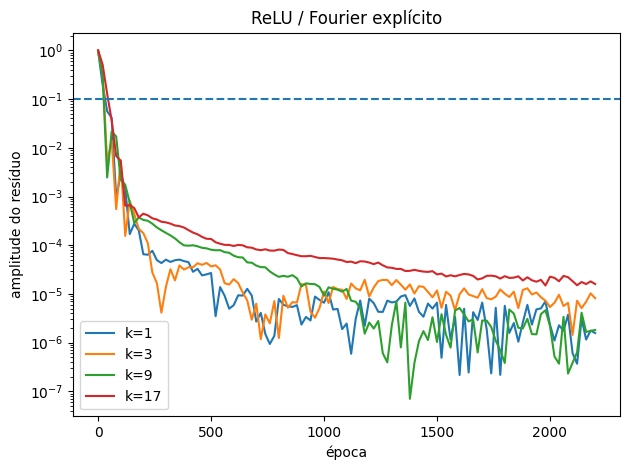

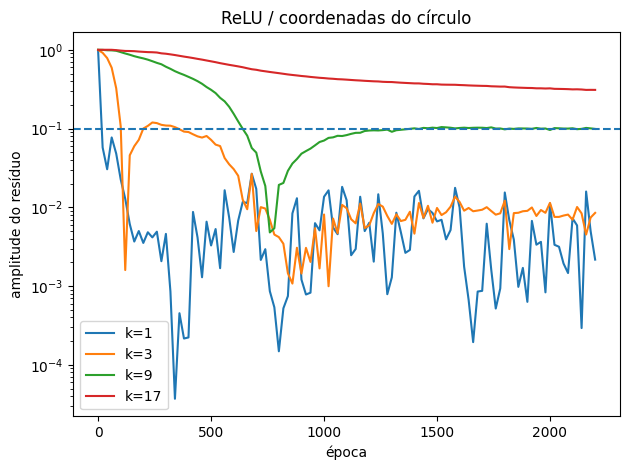

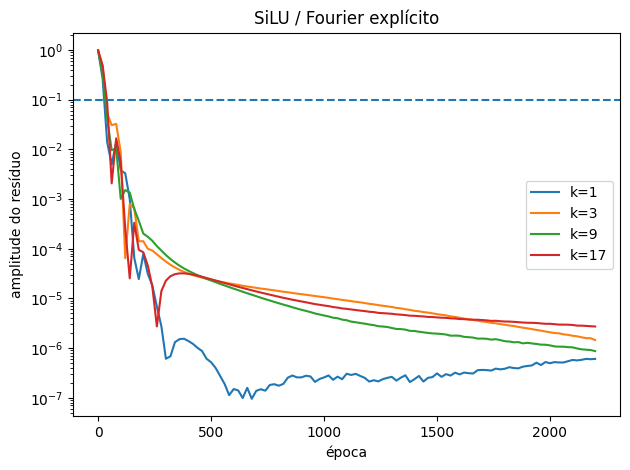

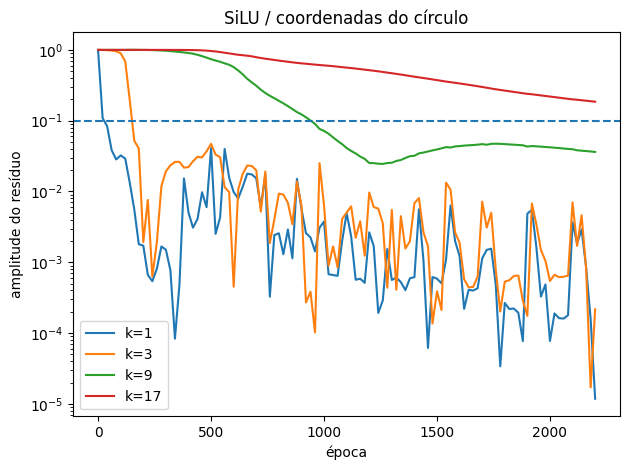

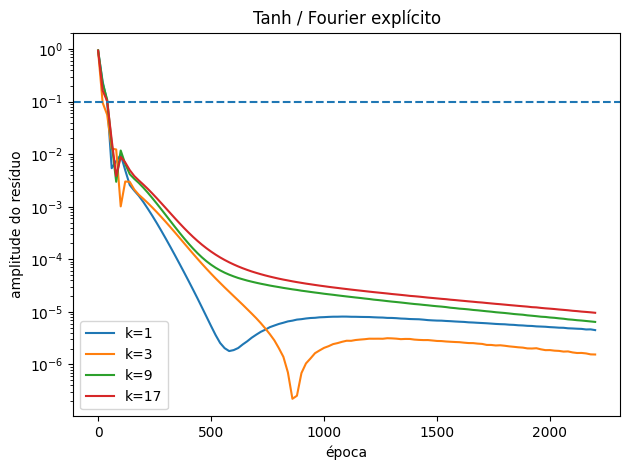

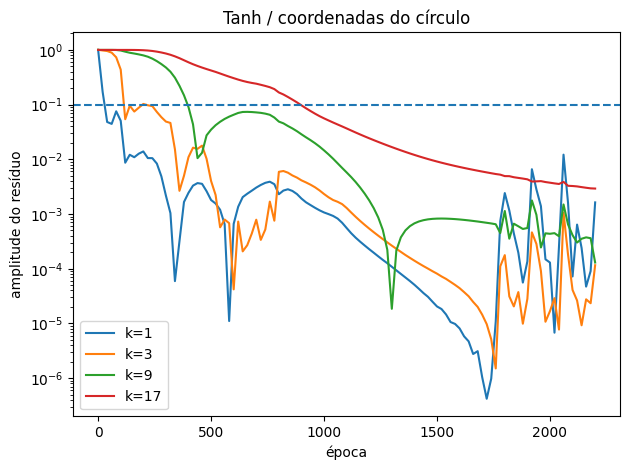

In [4]:
modes=np.array([1,3,9,17]);theta=np.linspace(0,2*np.pi,512,endpoint=False)
base=np.column_stack((np.cos(theta),np.sin(theta)))
S=np.sin(theta[:,None]*modes);y=S.sum(1)
FF=np.column_stack([fun(k*theta) for k in modes for fun in [np.cos,np.sin]])
coef=np.zeros(FF.shape[1]);coef[1::2]=1
assert np.max(abs(FF@coef-y))<1e-12
rows=[];residual_rows=[]
for activation in [nn.Tanh,nn.ReLU,nn.SiLU]:
    for label,X in [('coordenadas do círculo',base),('Fourier explícito',FF)]:
        net=mlp(X.shape[1],40,2,activation,seed=3)
        opt=torch.optim.Adam(net.parameters(),lr=.003)
        Tx=torch.tensor(X,dtype=torch.float32);Ty=torch.tensor(y,dtype=torch.float32).reshape(-1,1)
        crossings=np.full(len(modes),np.nan)
        for epoch in range(2201):
            if epoch%20==0:
                r=predict(net,X)-y;amp=np.abs(2*S.T@r/len(theta))
                for j,k in enumerate(modes):
                    if np.isnan(crossings[j]) and amp[j]<.1:crossings[j]=epoch
                    residual_rows.append(dict(ativacao=activation.__name__,entrada=label,epoca=epoch,modo=int(k),residuo=amp[j]))
            if epoch<2200:
                opt.zero_grad();loss=nn.functional.mse_loss(net(Tx),Ty);loss.backward();opt.step()
        for j,k in enumerate(modes):rows.append(dict(ativacao=activation.__name__,entrada=label,modo=int(k),primeiro_cruzamento=crossings[j],residuo_final=amp[j]))
        good=np.isfinite(crossings)&(crossings>0)
        if good.sum()>=3:print(activation.__name__,label,'expoente descritivo:',np.polyfit(np.log(modes[good]),np.log(crossings[good]),1)[0])
mode_df=table(rows,'ex03_tempos_modos',OUT);resid_df=table(residual_rows,'ex03_residuos',OUT)
for (act,features),g in resid_df.groupby(['ativacao','entrada']):
    plt.figure()
    for k,part in g.groupby('modo'):plt.semilogy(part.epoca,np.maximum(part.residuo,1e-8),label=f'k={k}')
    plt.axhline(.1,linestyle='--');plt.xlabel('época');plt.ylabel('amplitude do resíduo');plt.title(act+' / '+features);plt.legend()
    figure('ex03_'+act+'_'+('fourier' if features.startswith('Fourier') else 'circulo'),OUT)
write_summary(OUT.parent/'README.md','comparar capacidade de aproximação e treinamento das redes.',
'um alvo estar representável não garante que o otimizador o encontre.',
'foram testados crossover, Tanh/ReLU, curvas amostrais, oito sementes e quatro frequências.',
f"a representação ReLU de |z| foi exata; o ensemble de largura 32 teve MSE {ensemble_df.loc[ensemble_df.largura==32,'MSE_ensemble'].iloc[0]:.3g}.",
'as comparações são condicionadas às arquiteturas e ao orçamento de épocas; tempos de modos não atingidos permanecem censurados.')